# 12_01 — Simulación y preprocesamiento · Escenario 2 (Algoritmo 2 del anexo)

Paso **1 de 3** del ciclo `Python → MATLAB → Python`:

| Paso | Archivo | Qué hace |
|---|---|---|
| 1 | **este notebook** | genera los datos, ajusta base + FPCA + estandarizador, escribe los datasets AR y todos los artefactos |
| 2 | `psbp_fd_iteracion.m` | muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento |
| 3 | `12_03_convergencia` / `12_04_evaluacion` | diagnóstico de cadenas y evaluación fuera de muestra |

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de
experimento. Todo lo demás se deriva de ellas.

## 1. Imports y rutas

In [16]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenario2, generar_escenario_2, guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
from model_psbp_fd.utils import get_project_root
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento

In [17]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario"
ESCENARIO_ID = 2      # Algoritmo k del anexo
REPLICA_ID   = 1      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")

PROJECT_ROOT  : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_ID : escenario_2_r01
Escenario 2 · réplica 1 · seed base 41232


In [18]:
# Las cinco rutas del contrato. No existe un config_paths en Python: cada
# notebook lo arma aquí y config_paths.m replica las mismas del lado MATLAB.
PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for nombre, ruta in PATHS.items():
    ruta.mkdir(parents=True, exist_ok=True)
    print(f"  {nombre:12s} → {ruta}")

  raw          → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_2_r01
  functional   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_2_r01
  predict      → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_2_r01
  out_report   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_2_r01
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_2_r01


## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

El resto son propiedades del Algoritmo 2: `persistencia` y `prop_arch` (masa
total de la recursión de $\sigma_t^2$ y reparto entre el término ARCH y el
GARCH), `var_objetivo` (nivel estacionario de la varianza puntual),
`alcance_beta` y `alcance_gamma` (alcance de los dos núcleos) y `ell`
(suavidad de la innovación funcional).

In [19]:
# ── Parámetros fijos del estudio (comunes a los 6 escenarios) ────────────────
L_GRILLA   = 75     # puntos de la grilla regular tau_1=0 … tau_L=1
T_CURVAS   = 400    # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25   # desviación del ruido de medición

def media_senoidal(tau):
    """mu(tau) = sin(2 pi tau), Cuadro tab:ane_esquema. Con nombre para que
    quede legible en el JSON."""
    return np.sin(2.0 * np.pi * tau)

SIM_CFG = ConfigEscenario2(
    # Esquema de observación
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 200,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_senoidal,
    # Recursión de varianza condicional (Cuadro tab:ane_alg2)
    persistencia  = 0.85,
    prop_arch     = 0.25,
    var_objetivo  = 1.0,
    alcance_beta  = 0.15,
    alcance_gamma = 0.30,
    # Innovación funcional: correlación, no covarianza ⇒ E[eta^2] = 1 exacto
    ell       = 0.5,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<14}: {v}")

print(f"\nrazón señal/ruido esperada ≈ var_objetivo / sigma_obs^2 = "
      f"{SIM_CFG.var_objetivo / SIGMA_OBS**2:.1f}")

  L             : 75
  T             : 400
  burn_in       : 200
  sigma_obs     : 0.25
  R             : 1
  seed          : 41232
  media_fn      : media_senoidal
  jitter        : 1e-10
  persistencia  : 0.85
  prop_arch     : 0.25
  alcance_beta  : 0.15
  alcance_gamma : 0.3
  var_objetivo  : 1.0
  ell           : 0.5

razón señal/ruido esperada ≈ var_objetivo / sigma_obs^2 = 16.0


### 2.2 Generación

In [20]:
salida = generar_escenario_2(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — objetivo de evaluación
SIGMA2 = salida.internos["sigma2"][REPLICA_IDX]   # (T, G) varianza condicional LATENTE
grilla = salida.grilla
T, G   = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:32s} = {v}")

Observadas (400, 75) · verdaderas (400, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2503   (nominal 0.25)

Control de calidad del generador:
  n_replicas                       = 1
  n_curvas                         = 400
  n_puntos_grilla                  = 75
  todo_finito                      = True
  media_empirica_global            = -0.012333754568236592
  media_ee_montecarlo              = nan
  var_puntual_media                = 1.0840215738204269
  var_puntual_min                  = 0.9697562183011762
  var_puntual_max                  = 1.1618860306770102
  acf1_media                       = -0.004614434336561268
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = 17.34434518112683
  persistencia_objetivo            = 0.85
  norma_inf_BG                     = 0.85
  persistencia_error_absoluto      = 0.0
  radio_espectral_BG               = 0.7484305167498804
  estacionariedad_garantizada      = True
  sigma2_finito          

In [24]:
# Configuración de simulación + escenario completo en .npz
simulation_config = {
    "sim_params":    salida.config.to_dict(),
    "diagnostico":   salida.diagnostico,
    "replica_idx":   REPLICA_IDX,
    "experiment_id": EXPERIMENT_ID,
    "escenario_id":  int(ESCENARIO_ID),
    "replica_id":    int(REPLICA_ID),
    "seed":          SEED,
    "T": int(T), "G": int(G),
}
with open(PATHS["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
    json.dump(simulation_config, f, indent=2, ensure_ascii=False)

# incluir_internos=True es imprescindible AQUÍ: guarda `interno_sigma2`, la
# varianza condicional latente, que es el estado verdadero contra el cual 12_04
# estratifica la cobertura. Sin ella el eje 2 del diseño no se puede evaluar.
_npz = guardar_escenario(salida, str(PATHS["raw"] / f"escenario_{ESCENARIO_ID}"),
                         incluir_curvas=True, incluir_internos=True)
print(f"[raw] simulation_config.json  ·  {_npz}")

[raw] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_2_r01\escenario_2.npz


#### Control de calidad del generador

Tres cifras deciden si el escenario tiene contenido, y conviene mirarlas antes
de seguir:

- `radio_espectral_BG < 1` y `norma_inf_BG ≈ persistencia`: la solución
  estacionaria existe y la calibración es la pedida.
- `var_error_relativo` pequeño: el despeje de $\delta$ y el calentamiento
  dejaron la varianza puntual en su nivel teórico.
- `cv_temporal_sigma2` y `acf1_residuos_cuadrado` **claramente distintos de
  cero**: si ambos fueran ~0 el generador sería indistinguible del Escenario 1
  y el escenario no probaría nada.

In [21]:
_d = salida.diagnostico
_chequeos = [
    ("estacionariedad (rho < 1)",      _d["radio_espectral_BG"] < 1.0,
     f"rho={_d['radio_espectral_BG']:.4f}"),
    ("calibración de persistencia",    _d["persistencia_error_absoluto"] < 1e-8,
     f"||B+G||inf={_d['norma_inf_BG']:.4f} vs {_d['persistencia_objetivo']}"),
    ("sigma^2 positiva y finita",      _d["sigma2_positivo"] and _d["sigma2_finito"],
     f"[{_d['sigma2_min']:.3f}, {_d['sigma2_max']:.3f}]"),
    ("escala estacionaria",            _d["var_error_relativo"] < 0.25,
     f"error relativo {_d['var_error_relativo']:.1%}"),
    ("heterocedasticidad presente",    _d["cv_temporal_sigma2"] > 0.05,
     f"cv(sigma^2)={_d['cv_temporal_sigma2']:.3f}"),
    ("efecto ARCH detectable",         _d["acf1_residuos_cuadrado"] > 0.05,
     f"acf1(residuo^2)={_d['acf1_residuos_cuadrado']:.3f}"),
]
for nombre, ok, detalle in _chequeos:
    print(f"  {'✓' if ok else '✗'}  {nombre:32s} {detalle}")

assert all(ok for _, ok, _ in _chequeos[:4]), \
    "El generador no cumple las condiciones estructurales del Algoritmo 2."
if not all(ok for _, ok, _ in _chequeos[4:]):
    print("\n⚠ El mecanismo GARCH apenas se manifiesta: con estos parámetros el "
          "escenario\n  se parece al 1 y no discriminará entre modelos. Subir "
          "`persistencia` o `prop_arch`.")
    
print(f"\n  ·  curtosis marginal = {_d['curtosis_marginal']:.3f} "
      f"(exceso {_d['exceso_curtosis']:+.3f}; referencia gaussiana 3) "
      f"— informativo, no criterio")

  ✓  estacionariedad (rho < 1)        rho=0.7484
  ✓  calibración de persistencia      ||B+G||inf=0.8500 vs 0.85
  ✓  sigma^2 positiva y finita        [0.583, 4.132]
  ✓  escala estacionaria              error relativo 8.4%
  ✓  heterocedasticidad presente      cv(sigma^2)=0.381
  ✓  efecto ARCH detectable           acf1(residuo^2)=0.184

  ·  curtosis marginal = 3.338 (exceso +0.338; referencia gaussiana 3) — informativo, no criterio


#### Rasgo característico del Algoritmo 2

Figura propia de este escenario: la heterocedasticidad condicional, que es lo
único que lo separa del Escenario 1. Va aquí, antes de las figuras comunes a
los seis escenarios, porque es la evidencia gráfica de que el mecanismo que el
escenario existe para probar está presente.

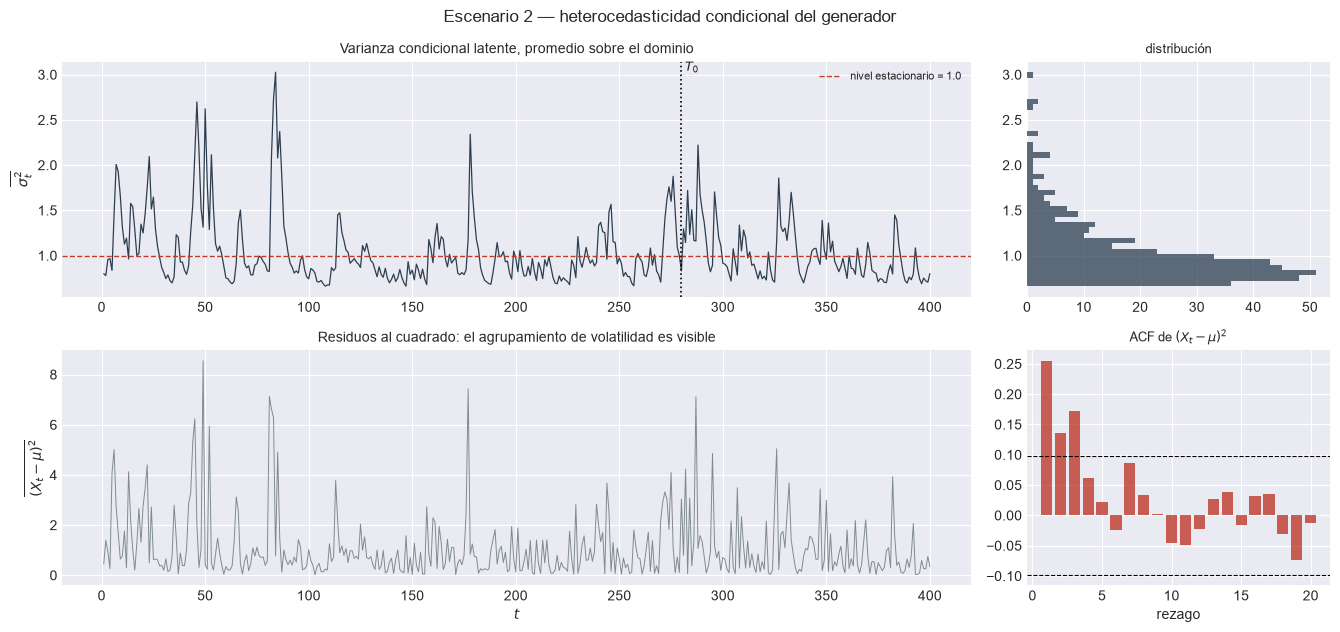

cv temporal de sigma^2   : 0.351
rango de sigma^2 (medio) : [0.662, 3.027]
razón alto/bajo (deciles): 2.04×


In [22]:
sigma2_med = SIGMA2.mean(axis=1)                       # (T,) estado de volatilidad
resid      = X_true - salida.media[None, :]            # (T, G) X_t - mu
resid_med2 = (resid ** 2).mean(axis=1)

T0_prev = int(np.floor(PROP_TRAIN * T))                # sólo para marcar el corte

fig, axes = plt.subplots(2, 2, figsize=(13.5, 6.4),
                         gridspec_kw={"width_ratios": [3, 1]})

ax = axes[0, 0]
ax.plot(np.arange(1, T + 1), sigma2_med, lw=0.9, color="#2c3e50")
ax.axhline(SIM_CFG.var_objetivo, color="#c0392b", ls="--", lw=1,
           label=f"nivel estacionario = {SIM_CFG.var_objetivo}")
ax.axvline(T0_prev, color="k", ls=":", lw=1.2)
ax.text(T0_prev, ax.get_ylim()[1], " $T_0$", fontsize=9, va="top")
ax.set_ylabel(r"$\overline{\sigma_t^2}$"); ax.legend(fontsize=8)
ax.set_title("Varianza condicional latente, promedio sobre el dominio", fontsize=10)

ax = axes[0, 1]
ax.hist(sigma2_med, bins=40, color="#2c3e50", alpha=0.75, orientation="horizontal")
ax.set_title("distribución", fontsize=9)

ax = axes[1, 0]
ax.plot(np.arange(1, T + 1), resid_med2, lw=0.7, color="#7f8c8d")
ax.set_xlabel("$t$"); ax.set_ylabel(r"$\overline{(X_t-\mu)^2}$")
ax.set_title("Residuos al cuadrado: el agrupamiento de volatilidad es visible",
             fontsize=10)

# ACF de los residuos al cuadrado: el estadístico clásico de efecto ARCH
ax = axes[1, 1]
z = resid_med2 - resid_med2.mean()
lags = np.arange(1, 21)
acf = np.array([np.sum(z[:-l] * z[l:]) / np.sum(z * z) for l in lags])
ax.bar(lags, acf, color="#c0392b", alpha=0.8)
ax.axhline(1.96 / np.sqrt(T), color="k", ls="--", lw=0.8)
ax.axhline(-1.96 / np.sqrt(T), color="k", ls="--", lw=0.8)
ax.set_xlabel("rezago"); ax.set_title(r"ACF de $(X_t-\mu)^2$", fontsize=9)

fig.suptitle("Escenario 2 — heterocedasticidad condicional del generador", fontsize=12)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "10_volatilidad_condicional.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"cv temporal de sigma^2   : {sigma2_med.std() / sigma2_med.mean():.3f}")
print(f"rango de sigma^2 (medio) : [{sigma2_med.min():.3f}, {sigma2_med.max():.3f}]")
print(f"razón alto/bajo (deciles): "
      f"{np.quantile(sigma2_med, 0.9) / np.quantile(sigma2_med, 0.1):.2f}×")

#### Persistencia del estado verdadero

Se guarda como CSV —y no sólo dentro del `.npz`— porque es el insumo del eje 2
de la evaluación y conviene que sea legible y versionable sin abrir un binario.
`12_04` lo lee de aquí; su nombre queda declarado en `eval_config.json`.

In [23]:
estado_df = pd.DataFrame({
    "t":           np.arange(1, T + 1),
    "sigma2_media": sigma2_med,
    "sigma2_min":   SIGMA2.min(axis=1),
    "sigma2_max":   SIGMA2.max(axis=1),
    "resid2_media": resid_med2,
})
estado_df.to_csv(PATHS["out_report"] / "10_estado_volatilidad.csv", index=False)
print(f"[out_report] 10_estado_volatilidad.csv  {estado_df.shape}")
display(estado_df.head())

[out_report] 10_estado_volatilidad.csv  (400, 5)


,t,sigma2_media,sigma2_min,sigma2_max,resid2_media
0,1,0.800029,0.696818,0.970896,0.446652
1,2,0.779318,0.681347,0.967000,1.390610
2,3,0.956898,0.787954,1.112583,0.938436
3,4,0.966317,0.899102,1.028803,0.266394
4,5,0.836317,0.780776,0.951942,4.067876


### 2.3 Visualización de los datos

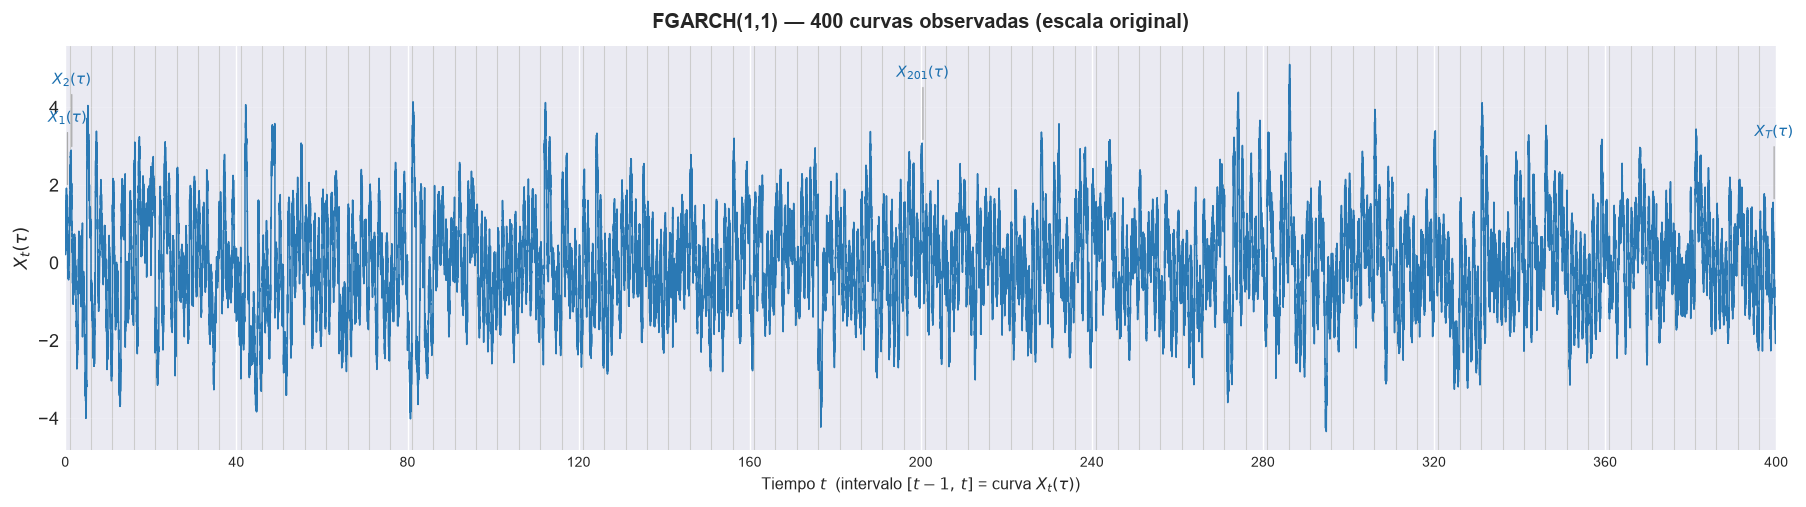

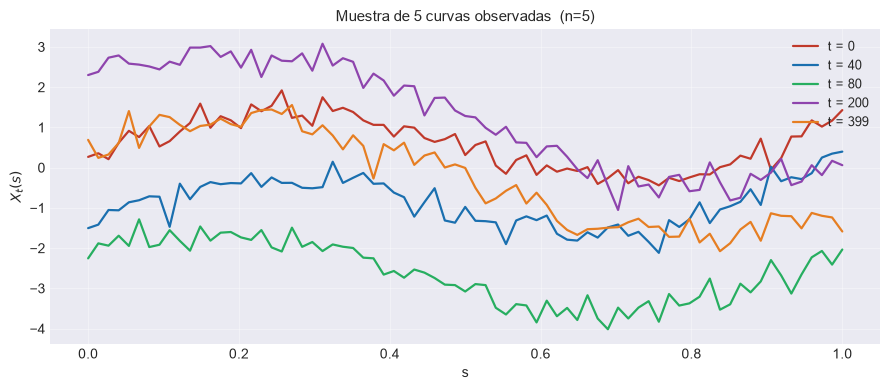

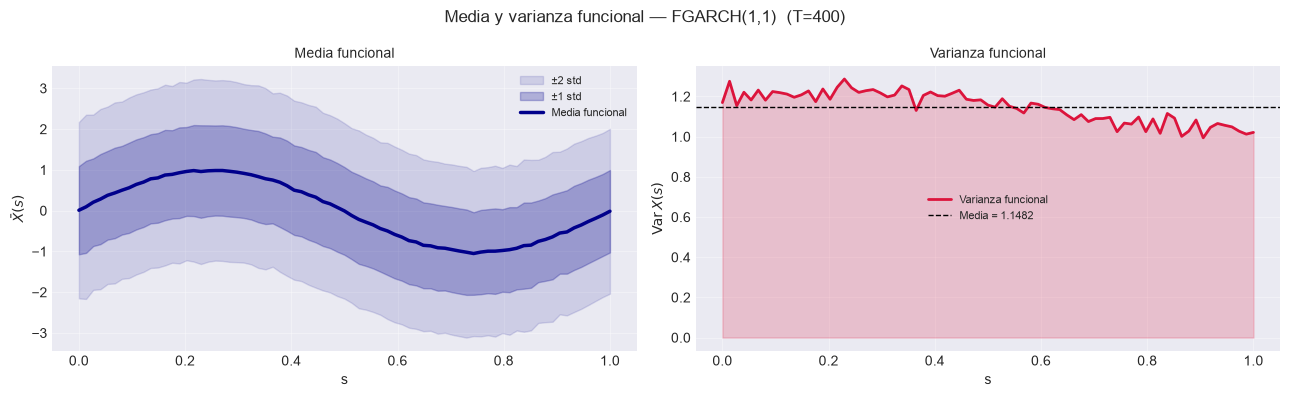

In [25]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"FGARCH(1,1) — {T} curvas observadas (escala original)",
    save_path=str(PATHS["out_report"] / "01_fts_empirica_raw.png"))
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas",
    save_path=str(PATHS["out_report"] / "02_muestra_empirica_raw.png"))
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — FGARCH(1,1)",
    save_path=str(PATHS["out_report"] / "03_media_varianza_raw.png"))
plt.show()

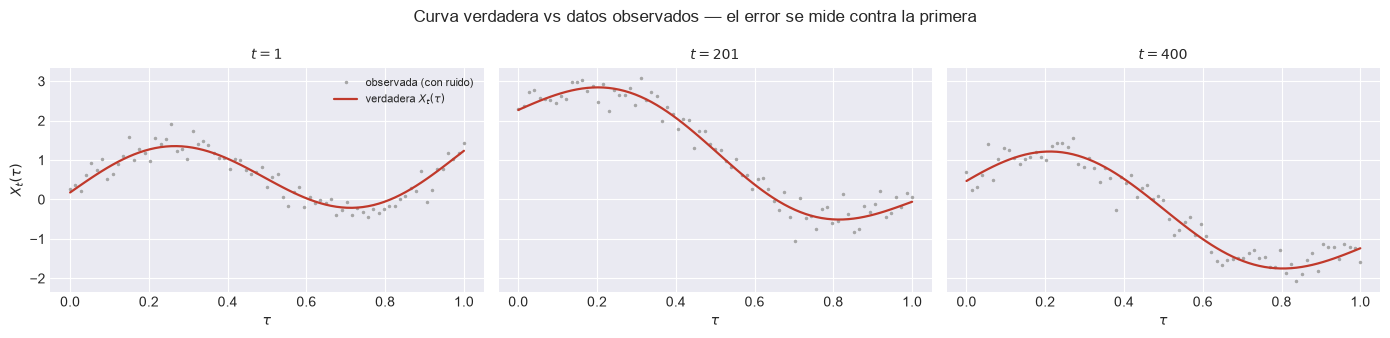

In [26]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "04_curva_vs_datos.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [27]:
_p = guardar_curvas(PATHS, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} → {ruta.name}")

[functional] curvas       → X_curves.npy
[functional] grilla       → domain_grid.npy
[functional] curvas_true  → X_curves_true.npy


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [28]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

# Aviso propio de este escenario: si los dos bloques cayeron en regímenes de
# volatilidad muy distintos, la comparación train/test de 12_04 mezclará el
# efecto de salir de muestra con el de un cambio de nivel de sigma^2.
_v_tr, _v_te = sigma2_med[idx_train].mean(), sigma2_med[idx_test].mean()
print(f"\nsigma^2 medio  train={_v_tr:.3f}   test={_v_te:.3f}   "
      f"razón={_v_te/_v_tr:.2f}×")
if not (0.75 < _v_te / _v_tr < 1.33):
    print("⚠ Los bloques difieren en volatilidad media: al leer 12_04, separar "
          "ese efecto\n  del de generalización usando la estratificación por "
          "estado (§9), no la marginal.")

entrenamiento : t ∈ [1, 280]      → (280, 75)
prueba        : t ∈ [281, 400]  → (120, 75)
proporción    : 70.0% / 30.0%

sigma^2 medio  train=1.048   test=1.010   razón=0.96×


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,73.7991%,0.550476,0.904669,0.326557
1,3,2,77.2845%,0.513520,0.744145,0.291036
2,4,2,93.3948%,0.278289,0.345182,0.087028
3,5,2,94.4881%,0.254188,0.316756,0.074712
4,6,2,94.8923%,0.244672,0.314869,0.071255
5,7,2,95.0478%,0.240965,0.318359,0.071133
6,8,2,95.1473%,0.238485,0.314954,0.071799
7,9,2,95.2410%,0.236148,0.309441,0.072564
8,10,2,95.3248%,0.234028,0.308129,0.073495
9,11,2,95.4082%,0.231904,0.308223,0.074457



GCV mínimo → n_basis=4, order=3  (var retenida 94.8103%)


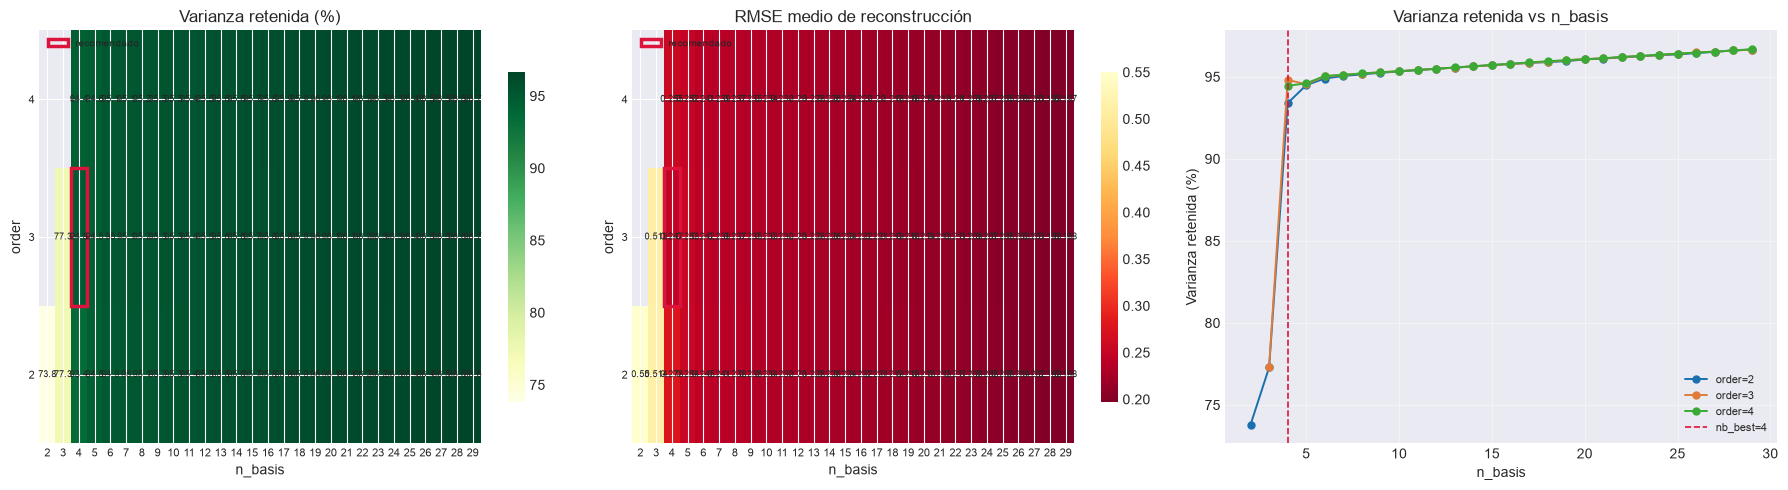

In [29]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best,
                     save_path=str(PATHS["out_report"] / "05_seleccion_basis.png"))
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=4, order=3
Sugerido GCV : n_basis=4, order=3   (coinciden)
THETA (400, 4)  (train=280, test=120)


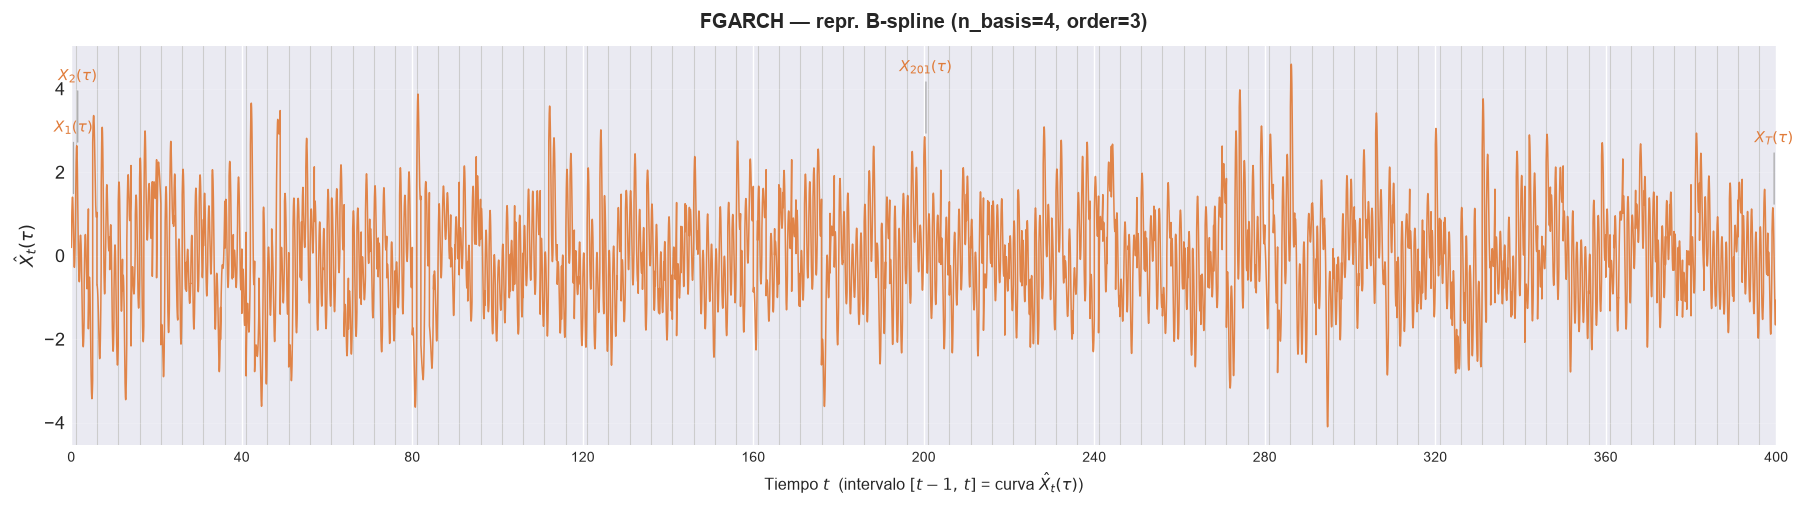

[functional] functional_representation.pkl + theta.csv + fr_config.json


In [30]:
NB_ELEGIDO  = 4     # ← decisión del analista
ORD_ELEGIDO = 3

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"FGARCH — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})",
    save_path=str(PATHS["out_report"] / "06_fts_funcional_bspline.png"))
plt.show()

guardar_representacion(PATHS, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print("[functional] functional_representation.pkl + theta.csv + fr_config.json")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [31]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 4
  K                                  = 4
  n_ajuste                           = 280
  cond_W                             = 9.439e+00
  err_ortonormalidad_L2              = 2.665e-15
  err_ortonormalidad_gram            = 2.442e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 4.441e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.871e-16
  err_media_scores_rel               = 8.378e-16
  err_var_scores_vs_lambda           = 7.772e-16
  err_var_scores_vs_lambda_rel       = 3.028e-15
  err_correlacion_lag0               = 7.817e-15
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

,componente,autovalor,var_ratio,var_acum,ar1_propio,ar1_cuadrado
0,1,8.9634e-01,79.6317%,79.6317%,-0.080,+0.314
1,2,1.9671e-01,17.4757%,97.1074%,+0.014,+0.038
2,3,2.8835e-02,2.5618%,99.6692%,+0.026,+0.048
3,4,3.7236e-03,0.3308%,100.0000%,+0.026,+0.103



K disponibles: 4   ·   sugerencia (var ≥ 95%): M = 2
máx |ar1_propio|   = 0.080   ← debería ser ≈ 0 (media condicional constante)
máx  ar1_cuadrado  = +0.314   ← aquí vive la dinámica del Algoritmo 2


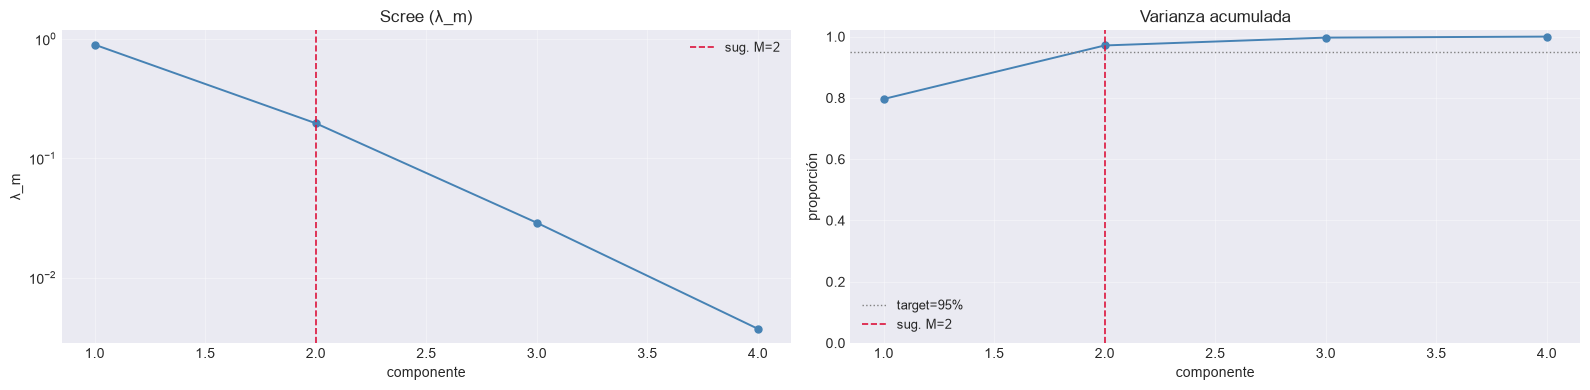

In [32]:
# Varianza ≠ dinámica. En este escenario la advertencia se agudiza: la media
# condicional es constante, de modo que el `ar1_propio` de todas las
# componentes debería ser ≈ 0. Que lo sea NO indica un problema: la dependencia
# está en el segundo momento y la ACF de los scores no la ve. La cantidad
# análoga que sí la ve es la ACF de los scores AL CUADRADO, que se agrega aquí.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

S2  = S_a ** 2
S2c = S2 - S2.mean(0)
ar1_cuad = (S2c[1:] * S2c[:-1]).sum(0) / np.clip((S2c ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum,
    "ar1_propio": ar1, "ar1_cuadrado": ar1_cuad,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}", "ar1_cuadrado": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1)
    .background_gradient(subset=["ar1_cuadrado"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")
print(f"máx |ar1_propio|   = {np.abs(ar1).max():.3f}   ← debería ser ≈ 0 (media "
      f"condicional constante)")
print(f"máx  ar1_cuadrado  = {ar1_cuad.max():+.3f}   ← aquí vive la dinámica del "
      f"Algoritmo 2")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET,
                save_path=str(PATHS["out_report"] / "07_fpca_scree.png"))
plt.show()

### 3.4 `[CONFIG]` Componentes FPCA retenidas

In [33]:
M_FPCA = 2   # ← lo fijas TÚ; igual que la corrida 11 para que M no sea un
             #   segundo factor en la comparación entre escenarios

assert 1 <= M_FPCA <= fpca.evals.size, f"M_FPCA fuera de [1, {fpca.evals.size}]."
fpca.set_M(int(M_FPCA))
M_fpca = fpca.M

Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
SCORES_train = SCORES[idx_train]
SCORES_test  = SCORES[idx_test]

print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
print(f"[train] max|media ξ| = {np.abs(SCORES_train.mean(0)).max():.2e}   (≈ 0)")
print(f"[test]  max|media ξ| = {np.abs(SCORES_test.mean(0)).max():.3f}")
print(f"[test]  var ξ / λ    = "
      f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")
print("\nEn este escenario `var ξ / λ` puede alejarse de 1 sin que la base esté "
      "mal ajustada:\nla varianza del proceso es variable en el tiempo y los dos "
      "bloques no tienen por qué\ncompartir nivel de volatilidad. Contrastar con "
      "la razón sigma^2 test/train de §2.5.")

M = 2   var. explicada = 97.1074%
[train] max|media ξ| = 2.87e-16   (≈ 0)
[test]  max|media ξ| = 0.018
[test]  var ξ / λ    = [0.862 1.039]

En este escenario `var ξ / λ` puede alejarse de 1 sin que la base esté mal ajustada:
la varianza del proceso es variable en el tiempo y los dos bloques no tienen por qué
compartir nivel de volatilidad. Contrastar con la razón sigma^2 test/train de §2.6.


## 4. Datasets AR($p$) sobre los scores

### 4.1 Estandarización

El estandarizador se ajusta **sólo con train** y registra `n_ajuste` para que
esa disciplina sea auditable desde el artefacto y no una promesa del notebook.

[holdout] ajustado con 280 filas = T0 (train[1:280]) → ok=True

SCORES_STD (400, 2)
  [train] max|media| = 2.18e-17  (≈0)
  [train] max|std-1| = 4.44e-16  (≈0)
  [test]  media = [-0.019 -0.024]
  [test]  std   = [0.926 1.017]

[functional] artefactos FPCA · cond_W = 9.439e+00


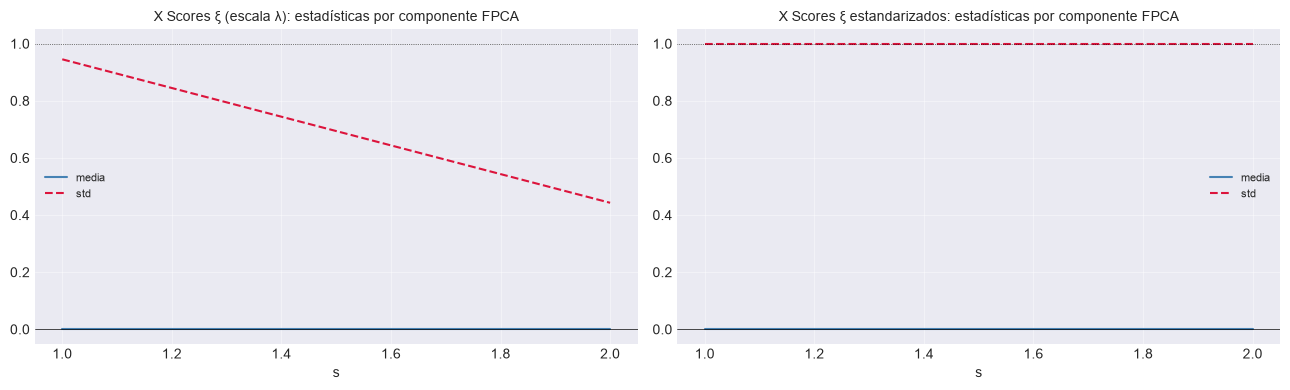

In [34]:
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

_chk = scores_standardizer.verificar_ajuste(T0)
print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
      f"({_chk['etiqueta_ajuste']}) → ok={_chk['ajuste_ok']}")

SCORES_STD       = scores_standardizer.transform(SCORES)
SCORES_STD_train = SCORES_STD[idx_train]
SCORES_STD_test  = SCORES_STD[idx_test]

print(f"\nSCORES_STD {SCORES_STD.shape}")
print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (≈0)")
print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (≈0)")
print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

guardar_estandarizador(PATHS, scores_standardizer)
_res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                    meta_extra={"T0": int(T0)})
print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

plot_diagnostico_estandarizacion(
    SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
plt.show()

### 4.2 Diagnóstico de rezagos (sólo train)

Los mapas de calor de correlación miden dependencia **en la media**, que en el
Algoritmo 2 es nula por construcción: lo esperable es un panel casi vacío. Se
conservan porque esa ausencia es en sí un resultado —confirma que el generador
no metió dependencia lineal por la puerta de atrás— y porque el mismo panel
sobre los **cuadrados** de los scores sí muestra la estructura, que es la que
el PSBPM debe recoger a través de los pesos de la mezcla.

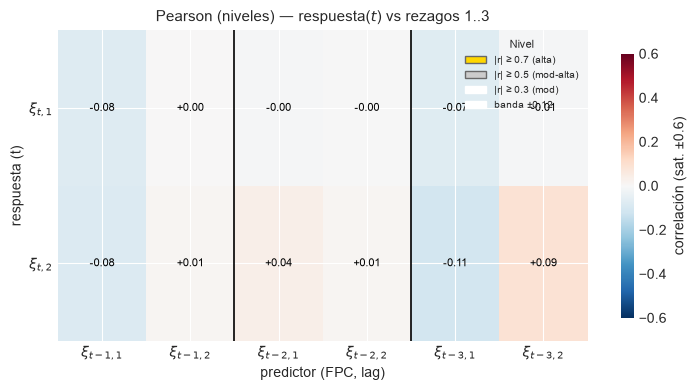

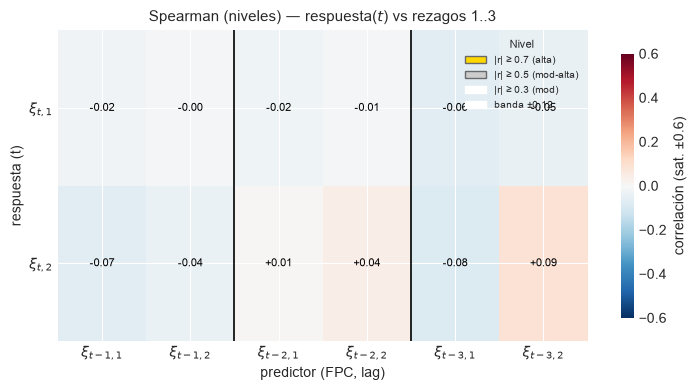

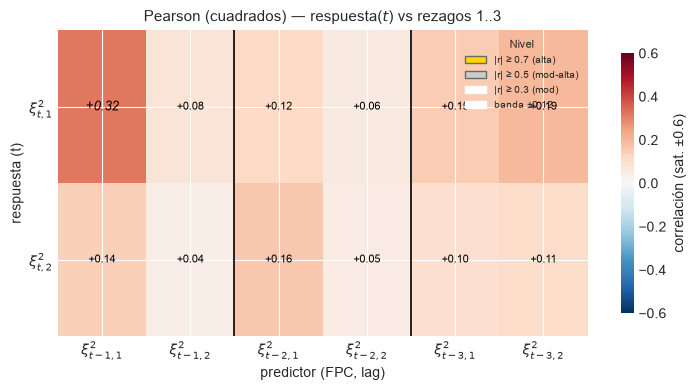

máx |corr| en niveles   : 0.112   (banda de ruido 0.118)
máx |corr| en cuadrados : 0.317

El contraste entre ambos números es el rasgo del Escenario 2: sin dependencia en la
media y con dependencia en la escala.


In [35]:
N_LAGS_MAX = 3
T_theta, K_total = SCORES_STD_train.shape

def _spearman(Y, Xm):
    """Spearman columna a columna vía rangos (pandas, sin scipy)."""
    Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
    Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

def _panel_correlaciones(Z):
    """Pearson y Spearman de Z(t) contra Z(t-1..t-N_LAGS_MAX)."""
    cp = np.zeros((K_total, K_total * N_LAGS_MAX))
    cs = np.zeros_like(cp)
    etiquetas = []
    y_block = Z[N_LAGS_MAX:, :]
    for lag in range(1, N_LAGS_MAX + 1):
        x_block = Z[N_LAGS_MAX - lag : Z.shape[0] - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                cp[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            cs[:, c] = sp[:, j]
            etiquetas.append((lag, j))
    return cp, cs, len(y_block)

corr_p, corr_s, n_eff = _panel_correlaciones(SCORES_STD_train)

Z2 = SCORES_STD_train ** 2
Z2 = (Z2 - Z2.mean(0)) / Z2.std(0)
corr_p2, corr_s2, _ = _panel_correlaciones(Z2)

col_labels  = [rf"$\xi_{{t-{lag},{j+1}}}$"
               for lag in range(1, N_LAGS_MAX + 1) for j in range(K_total)]
col_labels2 = [rf"$\xi^2_{{t-{lag},{j+1}}}$"
               for lag in range(1, N_LAGS_MAX + 1) for j in range(K_total)]
row_labels  = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
row_labels2 = [rf"$\xi^2_{{t,{k+1}}}$" for k in range(K_total)]
band = 1.96 / np.sqrt(n_eff)

for M_corr, cols, rows, nombre, arch in (
        (corr_p,  col_labels,  row_labels,  "Pearson (niveles)",   "09a"),
        (corr_s,  col_labels,  row_labels,  "Spearman (niveles)",  "09b"),
        (corr_p2, col_labels2, row_labels2, "Pearson (cuadrados)", "09c")):
    plot_rezagos_heatmap(
        M_corr, cols, rows,
        title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}",
        n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
        save_path=str(PATHS["out_report"] / f"{arch}_rezagos.png"))
    plt.show()

print(f"máx |corr| en niveles   : {np.abs(corr_p).max():.3f}   "
      f"(banda de ruido {band:.3f})")
print(f"máx |corr| en cuadrados : {np.abs(corr_p2).max():.3f}")
print("\nEl contraste entre ambos números es el rasgo del Escenario 2: sin "
      "dependencia en la\nmedia y con dependencia en la escala.")

### 4.3 `[CONFIG]` Orden AR y construcción de los datasets

Los rezagos del primer origen de prueba vienen del final del bloque de
entrenamiento: son observaciones pasadas disponibles en cada origen, de modo
que su uso es el condicionamiento de la predicción a $h=1$, no fuga.

`N_LAGS = 1` se mantiene igual que en la corrida 11. Basta para este
generador: la recursión de $\sigma_t^2$ es de orden uno en $(X_{t-1},
\sigma^2_{t-1})$, y aunque $\sigma^2_{t-1}$ no es observable, su dependencia de
la historia más lejana entra en el modelo por la vía de los pesos de la mezcla
y no exige rezagos adicionales en el predictor.

In [36]:
N_LAGS        = 1
COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

n_components = len(COMPONENT_IDX)
n_train_eff  = T0 - N_LAGS
n_test_eff   = T - T0

assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
             for lag in range(1, N_LAGS + 1)
             for j in range(n_components)]

print(f"componentes : {n_components} → índices {COMPONENT_IDX}")
print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
print(f"cov_names   : {cov_names}")

componentes : 2 → índices [0, 1]
N_LAGS      : 1   ·   p = 2 covariables
n_train_eff : 279   n_test_eff : 120
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1']


In [37]:
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

def _dataset_bloque(k, t_ini, t_fin):
    """Respuesta en t ∈ [t_ini, t_fin) y predictores en t-1 … t-N_LAGS."""
    t_idx  = np.arange(t_ini, t_fin)
    X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
    return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                        columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
    "ajuste_en": "train",
}
guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
for k in range(n_components):
    print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (279, 3) · test (120, 3)
  fpc_2: train (279, 3) · test (120, 3)


## 5. `[CONFIG]` Hiperparámetros y configuración MCMC

Esto es el **contrato con MATLAB**: `psbp_fd_iteracion.m` lee estos valores del
JSON y no los tiene escritos a mano, incluida `seed_base`.

Ojo con la doble acepción de `M`: aquí, dentro de `mcmc_config`, es el tamaño
de la grilla de localización $G^*$ del stick-breaking, **no** el número de
componentes FPCA. `N` es el truncamiento del número de átomos.

**Los priors son idénticos a los de la corrida 11 a propósito**, incluido el
`E[\pi]=0.90` sobre el propio rezago. Podría argumentarse que en este escenario
ese prior está mal orientado —no hay dependencia en la media—, pero cambiarlo
convertiría la comparación entre escenarios en una comparación entre
especificaciones a priori. Que el modelo tenga que *desmentir* un prior
favorable a la inclusión es, de hecho, la prueba interesante para el eje 3.

In [44]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 35, "M": 35}
N_CHAINS    = 3

print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS} cadenas por componente "
      f"→ {N_CHAINS * n_components} jobs en MATLAB")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) × {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

MCMC_CONFIG : {'nsim': 2000, 'burn': 500, 'N': 35, 'M': 35}
N_CHAINS    : 3 cadenas por componente → 12 jobs en MATLAB
Draws posteriores por score: (2000 - 500) × 3 = 4500


In [45]:
# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors por tipo de covariable: (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0, 0.0, 1.0),   # E[pi] = 0.90 — el propio rezago 1
    "cross_lag": (1.0, 1.0, 0.0, 1.0),   # E[pi] = 0.50 — los cruzados
}

def _clasificar(nombre, k_modelo):
    return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
            else "cross_lag")

HYPERPARAMS_LIST = []
for k in range(n_components):
    tipos = [_clasificar(nm, k) for nm in cov_names]
    vals  = np.array([HP_BY_TYPE[t] for t in tipos], dtype=float)   # (p, 4)
    HYPERPARAMS_LIST.append({**HP_GLOBAL,
        "apij": vals[:, 0], "bpij": vals[:, 1],
        "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
    for j, nm in enumerate(cov_names):
        a, b = hp["apij"][j], hp["bpij"][j]
        marca = "  ◄" if _clasificar(nm, k) == "own_lag1" else ""
        print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
              f"{a/(a+b):>7.3f}{marca}")


Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             cross_lag      1.0    1.0   0.500
  fpc_4_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_3_lag1             cross_lag      1.0    1.0   0.500
  fpc_4_lag1             cross_lag      1.0    1.0   0.500

Componente k=2  (fpc_3)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_4_lag1             cross_lag      1.0    1.0   0.500

Componente k=3  (fpc_4)
  vari

In [46]:
hp_artifact = {
    "global":       HP_GLOBAL,
    "by_type":      HP_BY_TYPE,
    "mcmc_config":  MCMC_CONFIG,
    "n_iter":       N_CHAINS,
    "seed_scheme":  "seed_base + chain*9973 + k*31",
    "escenario_id": int(ESCENARIO_ID),
    "replica_id":   int(REPLICA_ID),
    "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
    "scores_scale": "standardized_zscore_ddof0",
    "partition": {
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                        for k in range(n_components)],
        "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                        for k in range(n_components)],
    },
    "hyperparams_list": [
        {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
         "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                         for key, v in HYPERPARAMS_LIST[k].items()}}
        for k in range(n_components)
    ],
}
guardar_hiperparametros(PATHS, hp_artifact)
print(f"✓ hyperparameters.json → {PATHS['out_artefact']}")

✓ hyperparameters.json → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_2_r01


## 6. Configuración de evaluación, líneas base y verificación del contrato

`objetivo_evaluacion` y `modo_residuo` se declaran aquí porque cambian el
significado de toda la evaluación y no deben quedar como una decisión implícita
del notebook `_04`.

El bloque `estratificacion` es propio de este escenario: declara **cuál es el
estado verdadero** contra el que `12_04` estratifica la cobertura y dónde
leerlo. En el Escenario 1 no existía porque no hay estado que estratificar.

In [47]:
eval_config = {
    "scheme":      "holdout_temporal",
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "horizons":    [1],
    "n_lags":      int(N_LAGS),
    "scores_scale": "standardized_zscore_ddof0",
    # Contra QUÉ se mide el error y con qué banda. Declarado explícitamente:
    #   curva_verdadera + modo_residuo "ninguno" ⇒ la banda cubre la curva
    #   PROYECTADA sobre las M autofunciones y se contrasta con X_t(tau). Lo
    #   que queda fuera es truncamiento FPCA puro, sin el ruido de medición.
    "objetivo_evaluacion": "curva_verdadera",
    "modo_residuo":        "ninguno",
    "nivel_credibilidad":  0.95,
    "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
    "metrics_scores": ["RMSE", "R2", "razon_dispersion"],
    "metrics_curvas": ["MISE", "RMSE_funcional"],
    "metrics_dist":   ["CRPS", "energy_score", "cobertura_95", "PIT"],
    # Eje 2 del diseño: calibración condicional al estado VERDADERO del
    # generador. En el Algoritmo 2 el estado es el nivel de volatilidad.
    "estratificacion": {
        "variable":    "sigma2_media",
        "descripcion": "varianza condicional latente, promedio sobre el dominio",
        "fuente":      "reports/.../10_estado_volatilidad.csv",
        "respaldo":    f"raw/escenario_{ESCENARIO_ID}.npz::interno_sigma2",
        "n_estratos":  3,
        "etiquetas":   ["baja", "media", "alta"],
        "metodo":      "cuantiles sobre los orígenes evaluados",
    },
}
guardar_config_evaluacion(PATHS, eval_config)
print("[out_artefact] eval_config.json")
for k, v in eval_config.items():
    print(f"  {k:22s}: {v}")

[out_artefact] eval_config.json
  scheme                : holdout_temporal
  T                     : 400
  T0                    : 280
  prop_train            : 0.7
  horizons              : [1]
  n_lags                : 1
  scores_scale          : standardized_zscore_ddof0
  objetivo_evaluacion   : curva_verdadera
  modo_residuo          : ninguno
  nivel_credibilidad    : 0.95
  ventana_movil         : {'w': [10, 20, 40], 'paso': 1, 'solapadas': True}
  metrics_scores        : ['RMSE', 'R2', 'razon_dispersion']
  metrics_curvas        : ['MISE', 'RMSE_funcional']
  metrics_dist          : ['CRPS', 'energy_score', 'cobertura_95', 'PIT']
  estratificacion       : {'variable': 'sigma2_media', 'descripcion': 'varianza condicional latente, promedio sobre el dominio', 'fuente': 'reports/.../10_estado_volatilidad.csv', 'respaldo': 'raw/escenario_2.npz::interno_sigma2', 'n_estratos': 3, 'etiquetas': ['baja', 'media', 'alta'], 'metodo': 'cuantiles sobre los orígenes evaluados'}


### 6.1 Líneas base

Advertencia de lectura propia de este escenario: la **media incondicional** es
aquí la predicción puntual *óptima*, porque $\mathbb{E}[X_t\mid X_{t-1}]=\mu$.
Que el PSBPM-FD no le gane en RMSE no es un fracaso, y que le gane por poco
tampoco es un éxito; la comparación que importa se hace en `12_04` con CRPS,
puntaje de energía y cobertura condicional, donde una predictiva de ancho
constante —que es lo que toda línea base homocedástica entrega— sí pierde.

In [48]:
# Líneas base a h=1: el piso que el PSBP-FD debe superar.
baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                               fpca=fpca, X_obs=X_true, tau=grilla, h=1)
baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
display(baselines_df.style.format("{:.4f}", na_rep="—")
        .set_caption("Líneas base — bloque de prueba, h=1, contra la curva VERDADERA"))

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,120.0000,0.9736,0.9482,1.0370,1.0606,1.0049,-0.0006,0.9671,0.9834
persistencia_lag1,120.0000,1.2422,1.3662,1.4296,1.3966,1.3586,-0.8357,1.7351,1.3172


In [49]:
informe = verificar_contrato(PATHS)
print(f"contrato_ok = {informe['contrato_ok']}   "
      f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
      f"n_components={informe['n_components']})")
print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas (T0={informe['T0']})")
print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
if not informe["contrato_ok"]:
    print("\nPROBLEMAS:")
    for p in informe.get("problemas", []):
        print(f"  - {p}")

print(f"\n{'='*66}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"EXPERIMENT_ID = {EXPERIMENT_ID}\n{'='*66}")

contrato_ok = True   (M=4, K=8, T0=280, n_components=4)
estandarizador ajustado con 280 filas (T0=280)
verificación FPCA: todo_ok = True

Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
EXPERIMENT_ID = escenario_2_r01
